In [2]:
import pandas as pd
import numpy as np
import re

# Leggi il file CSV
df = pd.read_csv('/Users/edoardoconti/Downloads/results_ordinal_paper/results_pretrained.csv')

# Estrai il tipo di esperimento da 'experiment'
df['experiment_type'] = df['experiment'].apply(lambda x: re.search(r'_(obd|clm|resnet18|resnetQWK|cnnregstn)', x).group(1) if re.search(r'_(obd|clm|resnet18|resnetQWK|cnnregstn)', x) else 'unknown')

# rename
df['experiment_type'] = df['experiment_type'].replace('resnet18', 'resnet18 CCE')
df['experiment_type'] = df['experiment_type'].replace('resnetQWK', 'resnet18 QWK')

# Definisci le metriche da calcolare
metrics = ["ccr", "f1", "acc_1off", "acc_2off", "qwk", "spearman", "ms", "mae", "rmse"]

# Funzione per calcolare media e deviazione standard delle metriche
def calculate_stats(experiment_df):
    mean_values = experiment_df[metrics].mean()
    std_values = experiment_df[metrics].std()
    return mean_values, std_values

# Calcola media e deviazione standard per ogni tipo di esperimento
experiment_types = df['experiment_type'].unique()

# Stampa le medie e le deviazioni standard per ogni tipo di esperimento
for exp_type in experiment_types:
    exp_df = df[df['experiment_type'] == exp_type]
    mean_values, std_values = calculate_stats(exp_df)
    
    print(f"\nExperiment Type: {exp_type}")
    print("Mean Values:")
    print(mean_values)
    print("\nStandard Deviation Values:")
    print(std_values)


Experiment Type: cnnregstn
Mean Values:
ccr         0.614413
f1          0.620733
acc_1off    0.956733
acc_2off    0.996940
qwk         0.707020
spearman    0.733260
ms          0.381687
mae         0.442833
rmse        0.714200
dtype: float64

Standard Deviation Values:
ccr         0.041472
f1          0.035720
acc_1off    0.015307
acc_2off    0.003721
qwk         0.056086
spearman    0.042564
ms          0.112824
mae         0.066571
rmse        0.065627
dtype: float64

Experiment Type: resnet18 CCE
Mean Values:
ccr         0.570169
f1          0.564208
acc_1off    0.939669
acc_2off    0.987454
qwk         0.652992
spearman    0.670231
ms          0.328808
mae         0.502708
rmse        0.812385
dtype: float64

Standard Deviation Values:
ccr         0.064630
f1          0.070153
acc_1off    0.028542
acc_2off    0.025181
qwk         0.108812
spearman    0.101274
ms          0.113821
mae         0.089634
rmse        0.120969
dtype: float64

Experiment Type: resnet18 QWK
Mean Values:

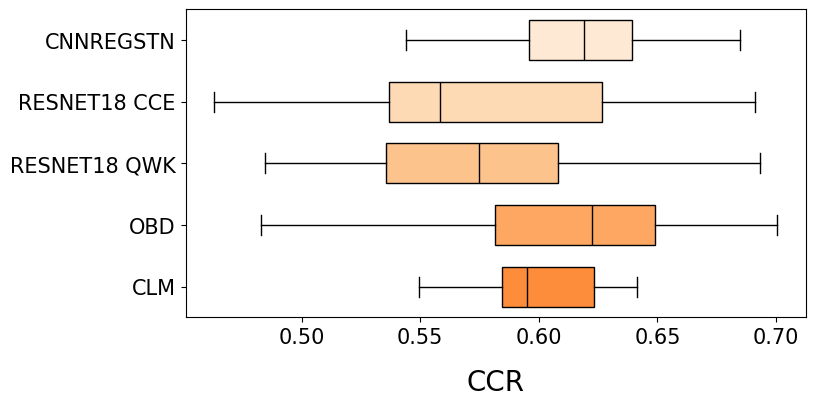

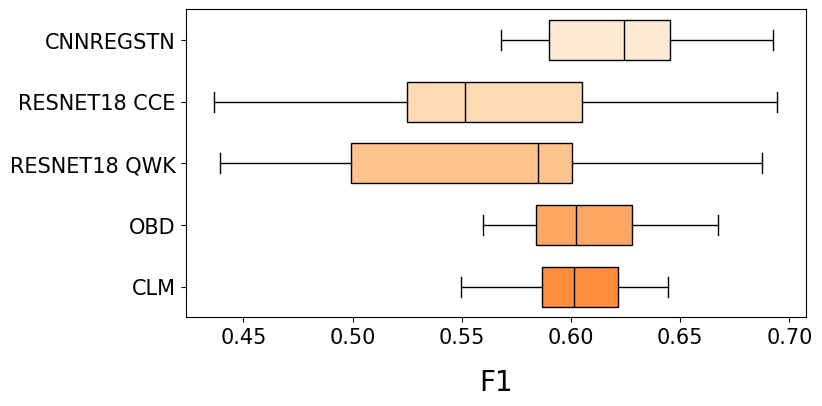

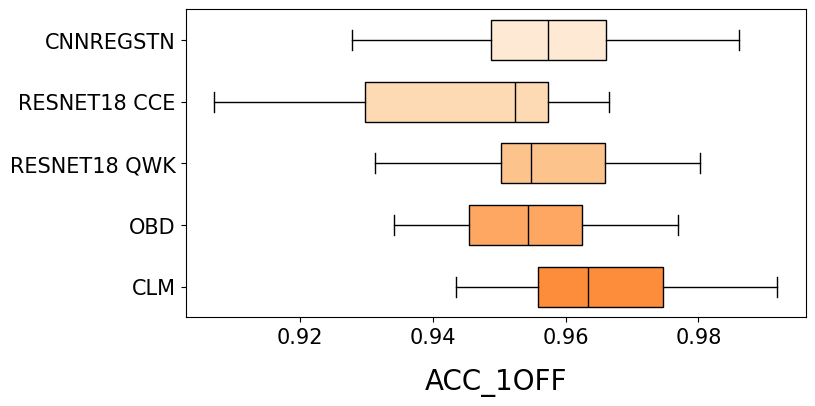

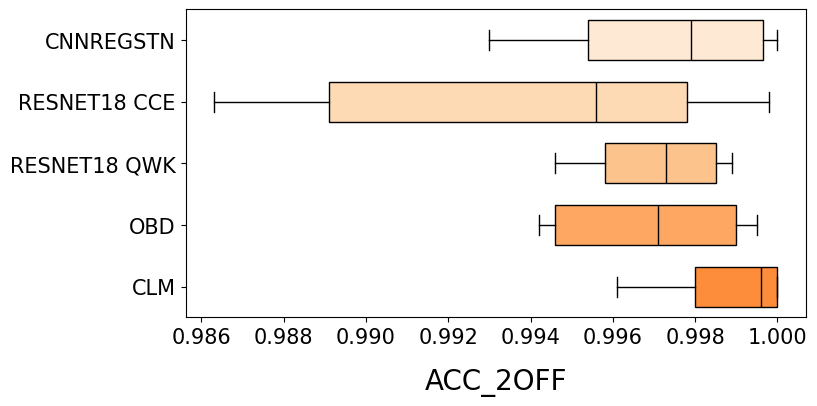

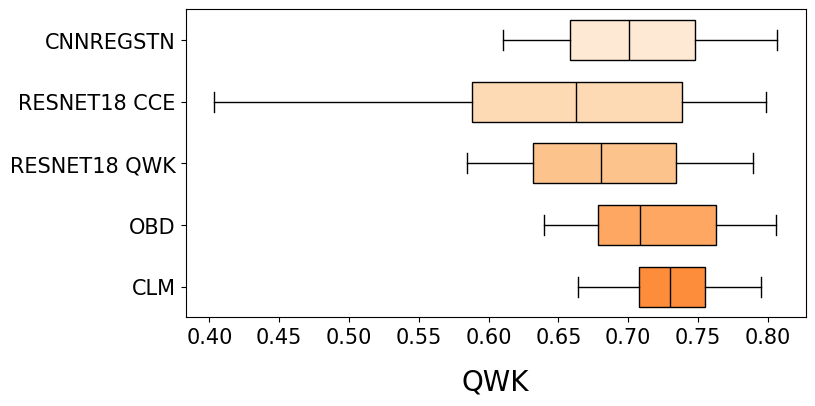

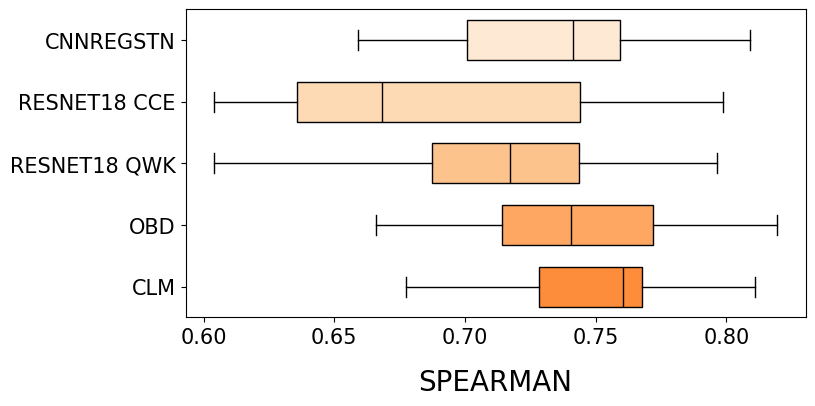

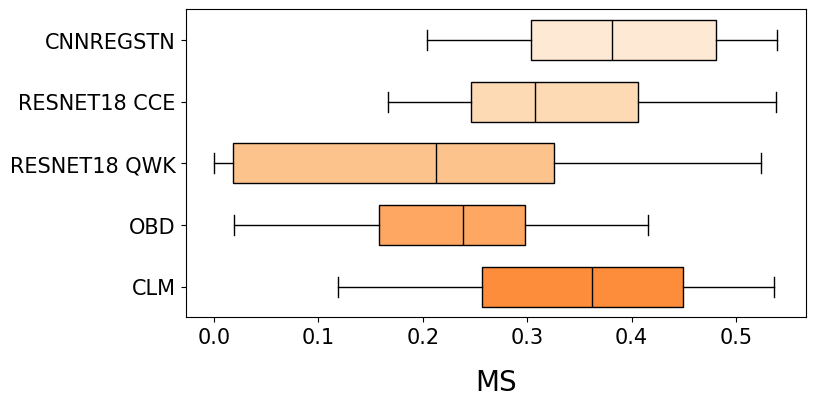

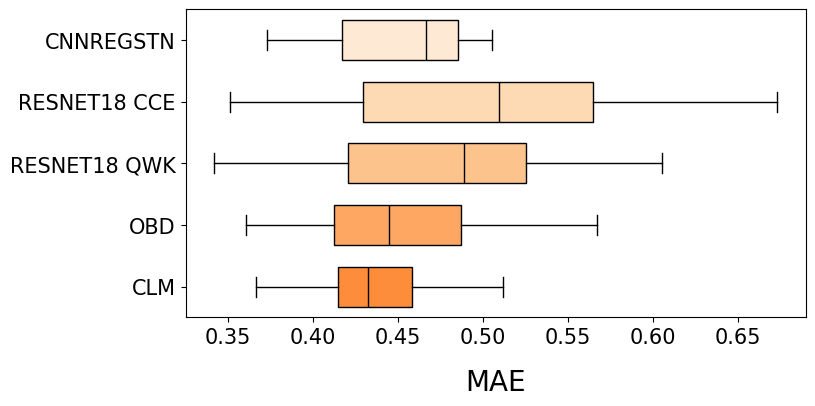

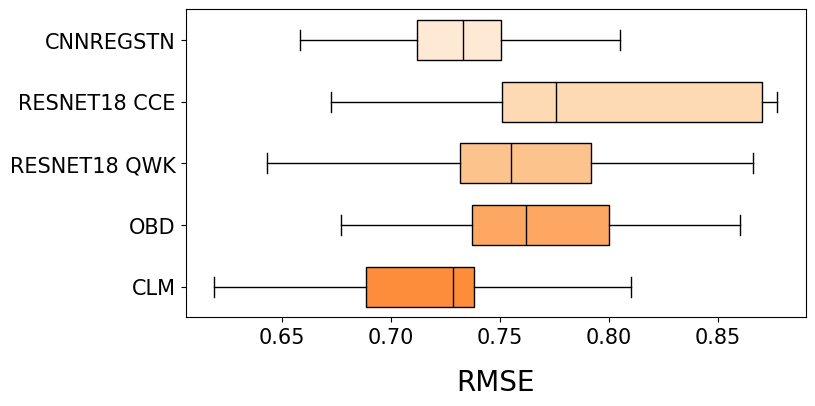

In [3]:
import matplotlib.pyplot as plt

for metric in metrics:
    plt.figure(figsize=(8, 4)) 
    positions = np.arange(len(experiment_types))
    positions = positions[::-1] #reverse

    medianprops = dict(linestyle='-', color='black')
    
    # Creazione del boxplot con colori
    box_plot = plt.boxplot([df[df['experiment_type'] == exp_type][metric] for exp_type in experiment_types], 
                           positions=positions, 
                           labels=[exp_type.upper() for exp_type in experiment_types],  # Rende maiuscole le etichette
                           showfliers=False,
                           vert=False,
                           widths=0.65,
                           patch_artist=True,
                           medianprops=medianprops
                           )
    
    # Specifica i colori e le gradazioni
    #colors = plt.cm.YlGn(np.linspace(0.1, 0.5, len(experiment_types)))
    colors = plt.cm.Oranges(np.linspace(0.1, 0.5, len(experiment_types)))
    
    # Assegna colori ai boxplot
    for i, box in enumerate(box_plot['boxes']):
        box.set_facecolor(colors[i])
    
    # Modifica la dimensione del font per le etichette
    plt.xlabel(metric.upper(), fontsize=20, labelpad=15)  # Aggiunge spazio sotto l'etichetta dell'asse x
    
    # Modifica la dimensione del font per le etichette degli assi
    plt.tick_params(axis='both', labelsize=15)
    
    plt.show()

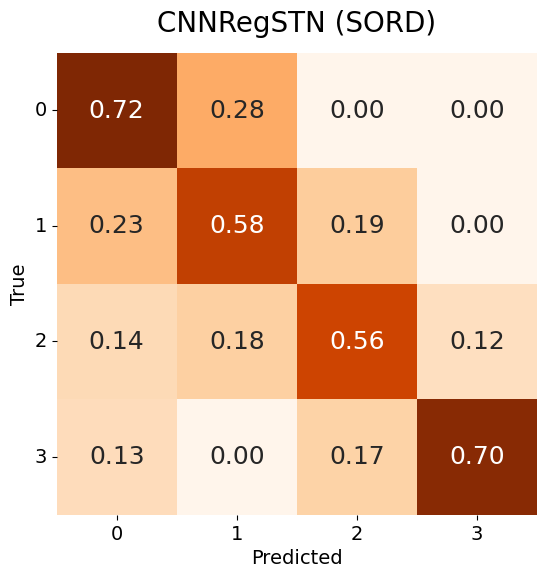

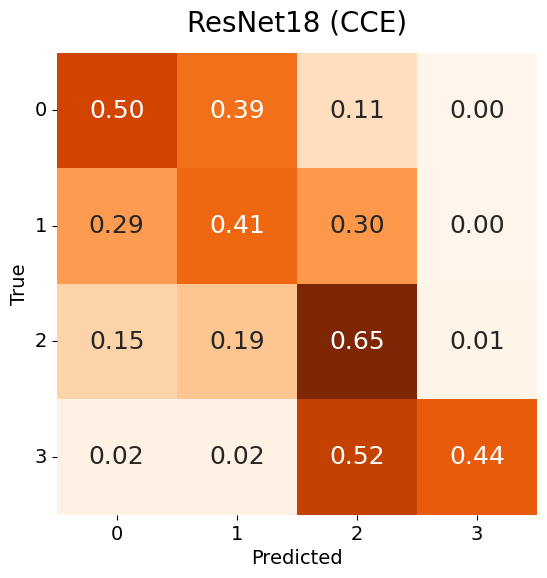

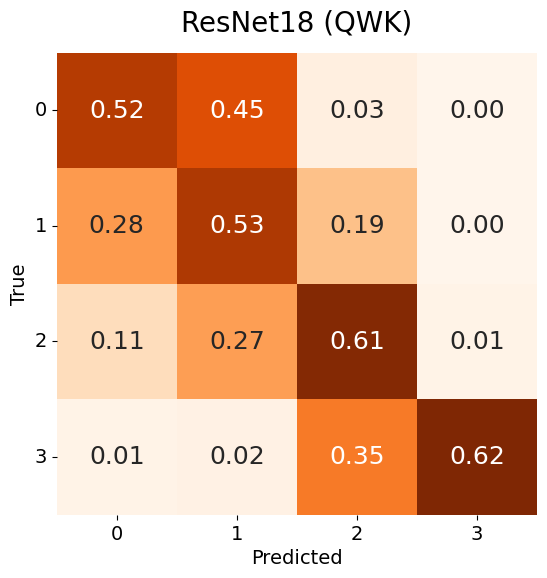

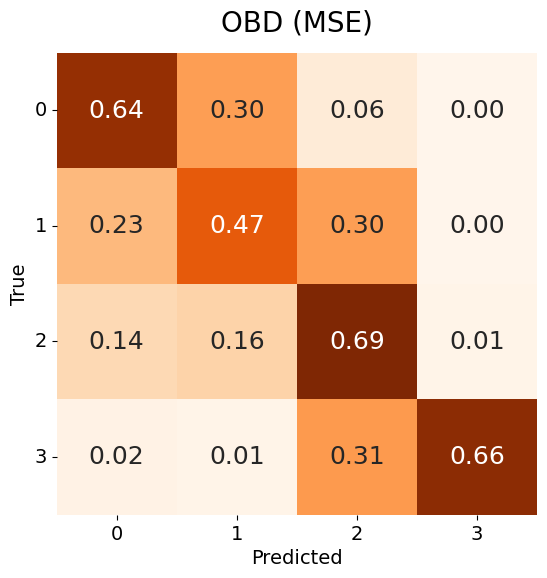

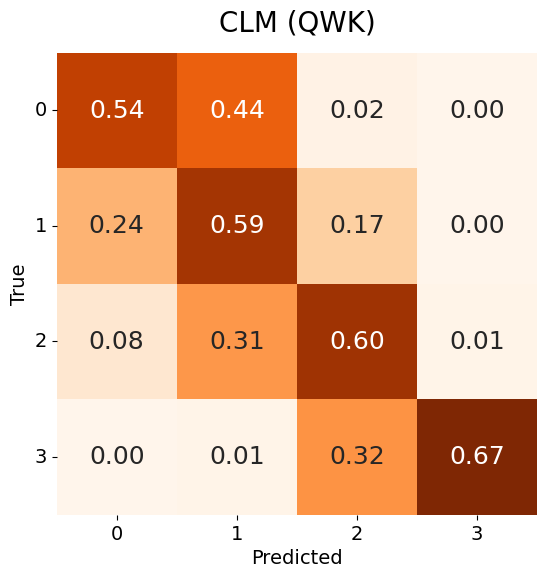

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(cm, title='Confusion matrix', cmap='Oranges', cbar=False):
    plt.figure(figsize=(8, 6)) if cbar else plt.figure(figsize=(6.2, 6))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap=cmap, cbar=cbar, annot_kws={"size": 18})
    plt.title(title, size=20, pad=15)
    plt.xlabel('Predicted', size=14)
    plt.ylabel('True', size=14)
    plt.xticks(np.arange(cm.shape[1]) + 0.5, range(cm.shape[1]), fontsize=14)
    plt.yticks(np.arange(cm.shape[0]) + 0.5, range(cm.shape[0]), fontsize=14, rotation=0)
    plt.show()

def plot_multiple_confusion_matrices(cms):
    for title, cm in cms:
        plot_confusion_matrix(cm, title=title)


cm_cnnregstn_sord = ["CNNRegSTN (SORD)", np.array([[0.72, 0.28, 0.00, 0.00],
                                             [0.23, 0.58, 0.19, 0.00],
                                             [0.14, 0.18, 0.56, 0.12],
                                             [0.13, 0.00, 0.17, 0.70]])]

cm_resnet_cce = ["ResNet18 (CCE)", np.array([[0.50, 0.39, 0.11, 0.00],
                                             [0.29, 0.41, 0.30, 0.00],
                                             [0.15, 0.19, 0.65, 0.01],
                                             [0.02, 0.02, 0.52, 0.44]])]

cm_resnet_qwk = ["ResNet18 (QWK)", np.array([[0.52, 0.45, 0.03, 0.00],
                                             [0.28, 0.53, 0.19, 0.00],
                                             [0.11, 0.27, 0.61, 0.01],
                                             [0.01, 0.02, 0.35, 0.62]])]

cm_obd_mse = ["OBD (MSE)", np.array([[0.64, 0.30, 0.06, 0.00],
                                     [0.23, 0.47, 0.30, 0.00],
                                     [0.14, 0.16, 0.69, 0.01],
                                     [0.02, 0.01, 0.31, 0.66]])]

cm_clm_qwk = ["CLM (QWK)", np.array([[0.54, 0.44, 0.02, 0.00],
                                     [0.24, 0.59, 0.17, 0.00],
                                     [0.08, 0.31, 0.60, 0.01],
                                     [0.00, 0.01, 0.32, 0.67]])]

# Lista delle matrici di confusione con i rispettivi titoli
cms = [cm_cnnregstn_sord, cm_resnet_cce, cm_resnet_qwk, cm_obd_mse, cm_clm_qwk]

# Chiamata alla funzione per stampare tutte le matrici
plot_multiple_confusion_matrices(cms)

In [220]:
import numpy as np

# Estrazione della matrice di confusione
_, cm = cm_cnnregstn_sord

# Calcolo delle metriche
true_positives = np.diag(cm)
false_positives = cm.sum(axis=0) - true_positives
false_negatives = cm.sum(axis=1) - true_positives
true_negatives = cm.sum() - (true_positives + false_positives + false_negatives)

# Calcolo della precisione e richiamo
precision = true_positives / (true_positives + false_positives)
recall = true_positives / (true_positives + false_negatives)

# Calcolo dell'F1 Score
f1_scores = 2 * (precision * recall) / (precision + recall)
f1_weighted = np.sum(f1_scores * (true_positives + false_negatives)) / np.sum(cm)

print(f"F1 Score: {f1_weighted:.2f}")

F1 Score: 0.64
